# Chebyshev's Inequality

Chebyshev's Inequality states that for any random variable $X$ with finite mean $\mu$ and finite variance $\sigma^2$,


$$
P(|X - \mu| < k \sigma) \geq 1 - \frac{1}{k^2}
$$


for any $k > 0$. In words, what this means is:

> *The probability that any value of a random variable will be within $k$ standard deviations away from the population mean of its probability distribution is at least $1 - \frac{1}{k^2}$.* 

The remarkable thing about Chebyshev's Inequality is that this statement holds **regardless of what that probability distribution is.** We will explore this in the following coding exercises.

Please be sure the `otter` initialization cell at the very top of the notebook and also the following cell before proceeding:

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. The Exponential Distribution
Consider the exponential distribution, with probability density function:

$$
f(x) = \lambda e^{-\lambda x}
$$
for $x \geq 0$ and $\lambda > 0$.

For the following exercises, let $X \sim Exponential(1)$, and $k=2$ in Chebyshev's Inequality, thus indicating that:

$$
P(|X - \mu| < 2 \sigma) \geq 1 -  \frac{1}{2^2}
$$

or in other words, the probability of observing a value that is at most 2 standard deviations away from the mean is at least $1 - \frac{1}{4} = 0.75$.

First, let's find $\mu$ and $\sigma$ and store them into variables.

**Question 1.1.** Find the value of $\mu$ for an $Exponential(1)$ random variable (e.g. from your memory, your textbook, an online source, or otherwise) and store it in the variable `mu` below.

In [3]:
mu = 1 # SOLUTION

In [4]:
# HIDDEN
bool(mu == 1)

True

**Question 1.2.** Likewise, find the value of $\sigma$ for an $Exponential(1)$ distribution and store it in the variable `sigma` below.

In [5]:
sigma = 1 # SOLUTION

In [6]:
# HIDDEN
bool(sigma == 1)

True

**Question 1.3.** Now, we will begin to simulate some data. Run the following line of code to simulate a single value from an $Exponential(1)$ distribution. After observing the value produced, re-run the line code a lot of times (at least 10 or so) and then answer the question below.

In [7]:
# Do not modify this code!
print(np.random.exponential(scale=1, size=1)[0])

1.5500489338493653


Which of the following best describes what you observed?
1. The values observed appear to be symmetric around the value of 1
2. The values observed appear to have a mean of 0
3. None of the values observed were less than 1
4. Most, if not all, of the values observed were less than 3
5. Close to 25% of the values observed were greater than 3

Choose from these options and set `obs_values` to 1, 2, 3, 4 or 5 corresponding to your answer choice. If you do not initially pass the grader check, re-run the code cell above more times until the correct answer becomes more apparent.

In [8]:
obs_values = 4 # SOLUTION

In [9]:
# HIDDEN
bool(obs_values == 4)

True

**Question 1.4.** First, run the following code to simulate 1,000,000 replicates from an $Exponential(1)$ distribution and plot a histogram:

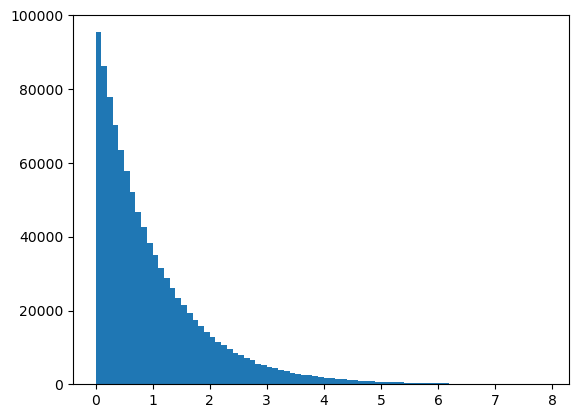

In [10]:
plt.hist(np.random.exponential(scale=1, size=1000000), bins=np.arange(0, 8, 0.1));

After briefly observing the histogram displayed above, our task now is to write code below to find a simulated estimate of $P(|X - \mu| < 2 \sigma)$. Recall again that Chebyshev's Inequality above tells us that:

$$
P(|X - \mu| < 2 \sigma) \geq 1 - \frac{1}{4}
$$

Our task here is to determine, via simulation, how close the real probability is to the Chebyshev bound of $1 - \frac{1}{4} = 0.75$. 

Note that, since an Exponential random variable cannot be negative and $2 \sigma > \mu$ in this case, this probability of interest simplifies to $P(X - \mu < 2 \sigma)$ which is also just equal to:

$$
P(X < 2\sigma + \mu)
$$ 
where $\mu$ and $\sigma$ are the values from **Question 1.1** and **Question 1.2**. This, therefore, is the probability that your code below ultimately needs to estimate. That is:

 - Simulate 10,000 observations of an $Exponential(1)$ random variable
 - Count the number of observations that satisfy the condition inside the above probability statement
 - Divide by the total number of observations (10,000) to get an estimate of that probability
 - Store the answer into `prop_geq2sig`.

Note that you may want to define other intermediate variables along the way, including (but not limited to) the provided `expn_sims` to first store your simulated values from the Exponential distribution.

In [11]:
expn_sims = np.random.exponential(scale=1, size=1000000) # SOLUTION
# BEGIN SOLUTION
count_geq3 = np.count_nonzero(expn_sims < 3)
prop_geq2sig = count_geq3 / 1000000
# END SOLUTION
prop_geq2sig

0.950275

In [12]:
# HIDDEN
bool(len(expn_sims) == 1000000)

True

In [13]:
# HIDDEN
bool(sum(expn_sims > 0) == 1000000)

True

In [14]:
# HIDDEN
bool((prop_geq2sig < 0.952) & (prop_geq2sig > 0.948))

True

## 2. Does skewness impact the accuracy of the Chebyshev bound?

Notice that your answer to **Question 1.4** should have been substantially larger than 0.75, indicating that the Chebyshev bound is a bit too conservative to really be useful in this case.

Here, we will explore the impact that skewness has on the tightness of the Chebyshev bound: that is, does a more skewed distribution give rise to probabilities that are any closer to the Chebyshev bound?

For this question, we will investigate the Gamma distribution. Recall that the Gamma distribution has two parameters: $\alpha$, also known as the `shape` parameter, and $\beta$, also known as the `scale` parameter. Further recall that if $X$ is a Gamma random variable, then:

$$
\begin{align*}
E(X) &= \alpha \beta \\
Var(X) &= \alpha \beta^2
\end{align*}
$$

or in other words, $\mu=\alpha \beta$ and $\sigma= \sqrt{\alpha \beta^2}$.

First, run the following code to plot histograms of two different Gamma distributions, holding `scale` = 1 and with different values of the `shape` parameter: 

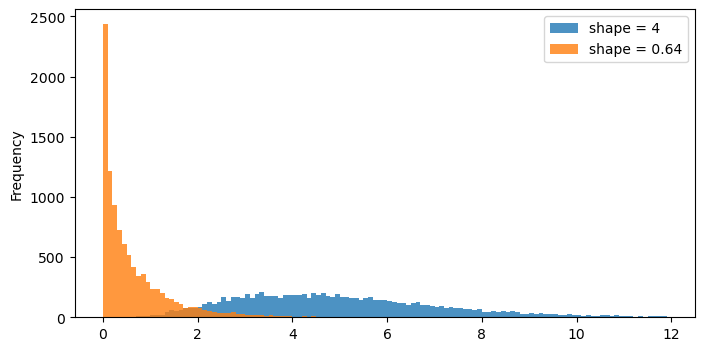

In [15]:
gammas = pd.DataFrame().assign(
    five = np.random.gamma(shape=5, scale=1, size=10000),
    pointsix = np.random.gamma(shape=0.64, scale=1, size=10000)
)

ax = gammas.plot(kind='hist', bins=np.arange(0, 12, 0.1), alpha=0.8, figsize=(8,4));
ax.legend(["shape = 4", "shape = 0.64"]);

(Note: these values of the shape parameter were chosen such that they have relatively nice square roots, which will come in handy for calculations below).

At a very general level, we can observe that the three distributions above have different skewness, driven by the value of the `shape` parameter in the distribution: the smaller the shape parameter is, the more skewed the distribution is. In the following questions, we will simulate according to these different `shape` parameter values and observe whether it appears to have an impact on the tightness of the Chebyshev bound.

### 2.1. Gamma distribution with $\alpha=4, \beta=1$.

**Question 2.1.1.** For a Gamma random variable with $\alpha=4, \beta=1$, determine the value of $\mu$ and store it into the variable `mu2_1_1` below.

In [16]:
mu2_1_1 = 4 # SOLUTION

In [17]:
# HIDDEN
bool(mu2_1_1 == 4)

True

**Question 2.1.2.** Again for a Gamma random variable with $\alpha=4, \beta=1$, determine the value of $\sigma$ and store it into the variable `sigma2_1_1` below.

In [18]:
sigma2_1_1 = 2 # SOLUTION

In [19]:
# HIDDEN
bool(sigma2_1_1 == 2)

True

**Question 2.1.3.** Now, similar to **Question 1.4**, we want to write code to find a simulated estimate of $P(|X - \mu| < 2 \sigma)$. Recall yet again that Chebyshev's Inequality tells us that:

$$
P(|X - \mu| < 2 \sigma) \geq 1 - \frac{1}{4}
$$

Our task here is to determine, via simulation, how close the real probability is to the Chebyshev bound of $1 - \frac{1}{4} = 0.75$ for this Gamma random variable. 

Note that, since a Gamma random variable cannot be negative just like the Exponential random variable, this probability of interest again ultimately simplifies to $P(X - \mu < 2 \sigma)$ which is also just equal to:

$$
P(X < 2\sigma + \mu)
$$ 
where $\mu$ and $\sigma$ are the values from **Question 2.1.1** and **Question 2.1.2**. This, therefore, is the probability that your code below needs to estimate. Specifically, in the code skeleton given below:

 - Simulate 10,000 observations of a Gamma random variable with $\alpha=4$, $\beta=1$
 - Assign the variable `twosig_plusmu1` to be the value of $2 \sigma + \mu$ for the present situation




In [21]:
gam1_sims = np.random.gamma(shape=4, scale=1, size=1000000) # SOLUTION
twosig_plusmu1 = 8 # SOLUTION
prop_geq2sig2_1_1 = np.count_nonzero(gam1_sims >= twosig_plusmu1) / 1000000
prop_geq2sig2_1_1

0.042561

In [22]:
# HIDDEN
bool(len(gam1_sims) == 1000000)

True

In [23]:
# HIDDEN
bool(sum(gam1_sims > 0) == 1000000)

True

In [24]:
# HIDDEN
bool(twosig_plusmu1 == 8)

True

In [25]:
# HIDDEN
bool((prop_geq2sig2_1_1 < 0.044) & (prop_geq2sig2_1_1 > 0.040))

True

### 2.2. Gamma distribution with $\alpha=0.64, \beta=1$.

Let us now repeat the above with a `shape` parameter of 0.64. As a `shape` parameter of 0.64 gives rise to a more skewed Gamma distribution, the question here is whether this will give a value of $P(X < 2\sigma + \mu)$ that is closer to the Chebyshev bound. 

We now just need to figure out what the value of $2 \sigma + \mu$ is in this case, and do the same procedure as in **Question 2.1.3.**

**Question 2.2.** Fill in the code below to find 

$$
P(X < 2 \sigma + \mu)
$$

for a Gamma random variable with $\alpha = 0.64$ and $\beta = 1$.

In [26]:
gam2_sims = np.random.gamma(shape=0.64, scale=1, size=1000000) # SOLUTION
twosig_plusmu2 = 2.24 # SOLUTION
prop_geq2sig2_2 = np.count_nonzero(gam2_sims < twosig_plusmu2) / 1000000
prop_geq2sig2_2

0.949274

In [27]:
# HIDDEN
bool(len(gam2_sims) == 1000000)

True

In [28]:
# HIDDEN
bool(sum(gam2_sims > 0) == 1000000)

True

In [29]:
# HIDDEN
bool(twosig_plusmu2 == 2.24)

True

In [30]:
# HIDDEN
bool((prop_geq2sig2_2 < 0.951) & (prop_geq2sig2_2 > 0.948))

True

### 2.3. Gamma distribution with $\alpha=0.01, \beta=1$.

In the previous two parts, we observed that the more highly skewed Gamma distribution (with `shape` = 0.64) came slightly closer to the Chebyshev bound than the less skewed Gamma distribution (with `shape` = 4).

Finally, we will repeat the above again, now with a `shape` parameter of 0.01 to give rise to an even more skewed distribution. We again just need to figure out what the value of $2 \sigma + \mu$ is in this case, and do the same procedure as in **Question 2.1.3.** and **Question 2.2.**

**Question 2.3.** Fill in the code below to find 

$$
P(X < 2 \sigma + \mu)
$$

for a Gamma random variable with $\alpha = 0.01$ and $\beta = 1$.

In [31]:
gam3_sims = np.random.gamma(shape=0.01, scale=1, size=1000000) # SOLUTION
twosig_plusmu3 = 0.21 # SOLUTION
prop_geq2sig2_3 = np.count_nonzero(gam3_sims < twosig_plusmu3) / 1000000
prop_geq2sig2_3

0.988153

In [32]:
# HIDDEN
bool(len(gam3_sims) == 1000000)

True

In [33]:
# HIDDEN
bool(sum(gam3_sims >= 0) == 1000000)

True

In [34]:
# HIDDEN
bool(twosig_plusmu3 == 0.21)

True

In [35]:
# HIDDEN
bool((prop_geq2sig2_3 < 0.991) & (prop_geq2sig2_3 > 0.987))

True

## 3. Chebyshev's Inequality and the Weak Law of Large Numbers

In the previous question, at first we thought that higher skewness gets us closer to the Chebyshev bound (**Question 2.1.3** vs. **Question 2.2**), but then the final case with even higher skewness (**Question 2.3**) gave us a probability that was extremely high! 

Overall, we have thus seen that it is pretty difficult to find a distribution such that Chebyshev's Inequality is reasonably tight. **So what good is it actually?**

Well, one of the most useful things about Chebyshev's Inequality is its relationship to the Weak Law of Large Numbers (WLLN). The following is the mathematical statement of the Weak Law of Large Numbers:

$$
\lim_{n \rightarrow \infty} P(|\overline{X} - \mu| < \epsilon) = 1
$$
for some arbitrarily small $\epsilon > 0$, and $\overline{X}$ is the mean of independent and identically distributed random variables $X_1, X_2, \ldots, X_n$. 

Note the structural similarity between this and Chebyshev's Inequality. In particular, if we wanted to mathematically prove that the WLLN is true, **one approach is to start from Chebyshev's Inequality as a known given, and show that the WLLN directly follows.** We will demonstrate this via simulation in this question.

In words, the WLLN basically says that sample means tend to get closer and closer to the true mean as you increase the sample size. This should feel very intuitively true! But, things that feel like they should be true intuitively are not always mathematically true, so it is important to have a mathematical proof of the WLLN.

As a first demonstration of the WLLN, the code below simulates from an $Exponential(1)$ distribution and calculates the mean: 
 - The first time that you run it, it will simulate just one value, so the mean will just be that value itself.
 - The second time that you run it, it will simulate a second value, and take the mean of those two values
 - and so on

In [36]:
# RUN THIS ONLY ONCE, OR IF YOU WANT TO START OVER
np.random.seed(44)
exp_sims = np.array([])

In [37]:
# RUN THIS REPEATEDLY
exp_sims = np.append(exp_sims, np.random.exponential(scale=1, size=1))
print(exp_sims)
if(len(exp_sims) == 1):
    print(f'\nThe mean of the {len(exp_sims)} value is {exp_sims.mean()}.')
else:
    print(f'\nThe mean of the {len(exp_sims)} values is {exp_sims.mean()}.')

[1.80085359]

The mean of the 1 value is 1.80085358764956.


**Question 3.1.** Run the above code **10 times**. Which of the following best describes what you observed?

1. The observed sample mean of the values was close to 1 the whole way
2. The observed sample mean started too high, but quickly got close to 1 and never got far away after that
3. The observed sample mean started too low, but quickly got close to 1 and never got far away after that
4. The observed sample mean started too high, then quickly got close to 1, but then diverged back away
5. The observed sample mean started too low, then quickly got close to 1, but then diverged back away

Choose from these options and set `expn_obs` to 1, 2, 3, 4 or 5 corresponding to your answer choice. 

In [38]:
expn_obs = 4 # SOLUTION

In [39]:
# HIDDEN
bool(expn_obs == 4)

True

Overall, we notice that 10 does not appear to be a high enough sample size to guarantee convergence of the sample mean to the true mean, but there's some suggestive evidence that it might get there. Tracking the sample mean up to a much larger sample size of 400 looks like this:

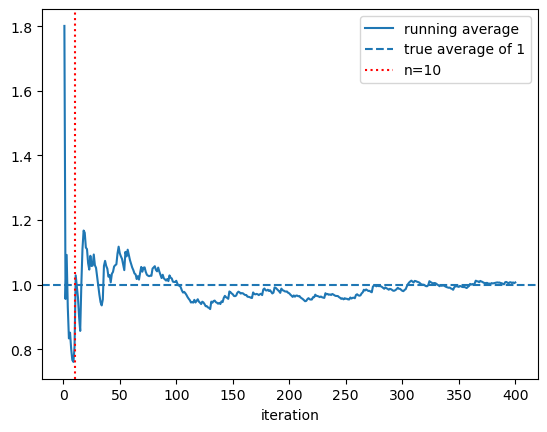

In [40]:
np.random.seed(44)
exp_sims = np.array([])
exp_sims_mean = np.array([])
for i in np.arange(400):
    exp_sims = np.append(exp_sims, np.random.exponential(scale=1, size=1))
    exp_sims_mean = np.append(exp_sims_mean, exp_sims.mean())

exp_df = pd.DataFrame({
    'iteration': np.arange(400) + 1,
    'mean': exp_sims_mean
})

exp_df.plot(kind='line', x='iteration', y='mean', label="running average");
plt.axhline(1, linestyle='--', label="true average of 1");
plt.axvline(10, linestyle='dotted', color='red', label="n=10");
plt.legend();

The averages to the left of the dotted red line are what we observed when repeatedly running the code above, and the blue solid line shows how much they went up and down. Notice that even after the red dotted line, it still has a fairly large amount of movement up and down, but then does eventually settle near the true average of 1. Let us continue to investigate this in the following questions.

**Question 3.2.** Now, let us directly compare the statements of Chebyshev's Inequality and the WLLN:

$$
\begin{align*}
\text{Chebyshev:}&& P(|X - \mu| < k \sigma) &\geq 1 - \frac{1}{k^2} \\
\text{WLLN: }&& \lim_{n \rightarrow \infty} P(|\overline{X} - \mu| < \epsilon) &= 1
\end{align*}
$$

We notice that they look remarkably similar but with some key differences, two of them being:
 - $\overline{X}$ is in place of $X$
 - $\epsilon$ is in place of $k \sigma$

With this in mind, the first question we should ask if we want to get from Chebyshev's Inequality to the WLLN is, if $\overline{X}$ is the mean of independent and identically distributed random variables $X_1, X_2, \ldots, X_n$ each with standard deviation $\sigma$, then what is the standard deviation of $\overline{X}$?

Select the right answer choice:
1. $\sigma$
2. $\sigma / n$
3. $\sigma / \sqrt{n}$
4. $\sigma^2/n$

Store the value of 1, 2, 3 or 4 into the variable `se` below:

In [41]:
se = 3 # SOLUTION

In [42]:
# HIDDEN
bool(se == 3)

True

**Question 3.3.** With the answer to the previous question in mind, we start from Chebyshev's Inequality and:

 - Replace $X$ with $\overline{X}$
 - Replace $\sigma$ (which is the standard deviation of $X$) with the standard deviation of $\overline{X}$ from the previous question

to arrive at:

$$
P\bigg(|\overline{X} - \mu| < \frac{k \sigma}{\sqrt{n}}\bigg) \geq 1 - \frac{1}{k^2}
$$

Now, recall again the statement of the WLLN:

$$
\lim_{n \rightarrow \infty} P(|\overline{X} - \mu| < \epsilon) = 1
$$

Examining these two statements, it appears that in order to continue traversing from Chebyshev's Inequality to the WLLN, perhaps we should replace $\frac{k \sigma}{\sqrt{n}}$ with $\epsilon$ in the first of the above two statements. Which of these choices then directly follows from doing so?
1. $P(|\overline{X} - \mu| < \epsilon) \geq 1 - \frac{1}{n}$
2. $P(|\overline{X} - \mu| < \epsilon) \geq 1 - \frac{\sigma}{\epsilon \sqrt{n}}$
3. $P(|\overline{X} - \mu| < \epsilon) \geq 1 - \frac{\sigma^2}{n}$
4. $P(|\overline{X} - \mu| < \epsilon) \geq 1 - \frac{\sigma^2}{\epsilon^2 n}$

Store the value of 1, 2, 3 or 4 in `func_of_k` below.

In [43]:
func_of_k = 4

In [44]:
# HIDDEN
bool(func_of_k == 4)

True

**Question 3.4.** Now, recall that $\epsilon$ is meant to be an arbitrarily small value. Let us start with a value of $\epsilon = 0.05$. 

And again utilizing the $Exponential(1)$ distribution (which has $\mu=1$ and $\sigma=1$), first run this code to simulate 400 replicates and calculate its mean:

In [45]:
print(np.random.exponential(scale=1, size=400).mean())

1.0705896700064466


Then, run it repeatedly, until you observe a value that is greater than 0.05 away from the mean of 1 (so, less than 0.95 or greater than 1.05). Notice that it could in fact occur quite readily. 

The following code now simulates 100,000 samples of size 400, and each time calculating the mean and storing it, for a total of 100,000 means (it may take several seconds or so):

In [46]:
expn_means = np.array([])
reps = 100000
for i in np.arange(reps):
    expn_means = np.append(expn_means, np.random.exponential(scale=1, size=400).mean())

expn_means

array([0.97433241, 0.95393746, 1.00063528, ..., 1.08046541, 0.99923054,
       1.06059231], shape=(100000,))

Now, write code to count the proportion of `expn_means` that is within 0.05 of the true mean of 1.

In [47]:
prop_within01 = np.count_nonzero((expn_means > 0.95) & (expn_means < 1.05)) / reps # SOLUTION
prop_within01

0.6836

In [48]:
# HIDDEN
bool((prop_within01 > 0.68) & (prop_within01 < 0.69))

True

**Question 3.5** Below is a function that takes in two inputs: `n` and `eps`, and returns the proportion of the time that the sample mean from a sample of size `n` from an Exponential(1) distribution is within `eps` of the true mean. Give it a variety of inputs and then use you observations to answer the question beneath it.

Specifically, first see what happens when you increase `n`. Then see what happens when you decrease `eps`. Then increase `n` again, etc.

In [49]:
# RUN THIS CODE BLOCK BUT BE SURE NOT TO MODIFY IT
def prop_within_eps(n, eps):
    means = np.array([])
    reps = 10000
    for i in np.arange(reps):
        means = np.append(means, np.random.exponential(scale=1, size=n).mean())

    return np.count_nonzero((means > (1 - eps)) & (means < (1 + eps))) / reps

In [50]:
# Run this with various values of n and eps
prop_within_eps(n=10000, eps=0.01)

0.6882

Which of the following best describes what you observed?
1. No matter how small you make `eps`, you can always find an `n` that will make the probability of $\overline{X}$ falling within `eps` of the true mean very close to 1.
2. `n` has no impact on the probability $\overline{X}$ falling within `eps` of the true mean
3. `eps` has no impact on the probability $\overline{X}$ falling within `eps` of the true mean
4. A sample size of $n=10,000$ is big enough to make sure that $\overline{X}$ is almost always within $1\%$ of the true mean

Store the value of 1, 2, 3 or 4 into `prop_w_eps` below.

In [51]:
prop_w_eps = 1 # SOLUTION

In [52]:
# HIDDEN
bool(prop_w_eps == 1)

True

## Congratulations, you are finished!!

To submit your assignment:

1. Select `Kernel -> Restart & Run All` to ensure that you have executed all cells, including the test cells.
2. Read through the notebook to make sure everything is fine and all tests passed.
3. Run the cell below to run all tests, and make sure that they all pass.
4. Download your notebook using `File -> Download as -> Notebook (.ipynb)`, then upload your notebook to Gradescope.
5. Stick around while the Gradescope autograder grades your work. Make sure you see that all tests have passed on Gradescope.
6. Check that you have a confirmation email from Gradescope and save it as proof of your submission.

In [ ]:
# For your convenience, you can run this cell to run all the tests at once!
grader.check_all()